In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder

In [51]:
data_promo = {
    'Experience_Years': [2,4,2,3,6,5],
    'Performance_Rating': [3,4,5,3,4,4],
    'Promoted': ['No','Yes','Yes','No','Yes',None]
}
df = pd.DataFrame(data_promo)
print('Dataset')
display(df)

Dataset


,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,2,5,Yes
3,3,3,No
4,6,4,Yes
5,5,4,None


In [52]:
# Clean the data
df = df.dropna()

In [53]:
df

,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,2,5,Yes
3,3,3,No
4,6,4,Yes


In [54]:
# Split the data
X = df[['Experience_Years','Performance_Rating']]
y = df['Promoted']

In [55]:
model = DecisionTreeClassifier()

In [56]:
model.fit(X,y)

DecisionTreeClassifier()

In [57]:
predict = model.predict([[5,4]])
print('Promotion Prediction is: ', predict[0])

Promotion Prediction is:  Yes


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


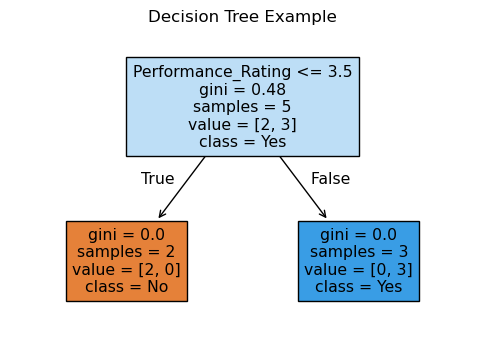

In [59]:
plt.figure(figsize=(6,4))
plot_tree(model,
    feature_names = ['Experience_Years','Performance_Rating'],
    class_names = ['No','Yes'],
    filled=True
)
plt.title('Decision Tree Example')
plt.show()

# Take the experience years and performance rating from user and display promoted or not promoted usinf prediction
# write code in this way, there should be no warning message
# exp years
# per_rating
# print ('Promoted')

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder

In [68]:
data_promo = {
    'Experience_Years': [2,4,2,3,6,5],
    'Performance_Rating': [3,4,5,3,4,4],
    'Promoted': ['No','Yes','Yes','No','Yes',None]
}
df = pd.DataFrame(data_promo)
print('Dataset')
display(df)

Dataset


,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,2,5,Yes
3,3,3,No
4,6,4,Yes
5,5,4,None


In [71]:
le=LabelEncoder()
df['Promoted'] = le.fit_transform(df['Promoted'])
X = df[['Experience_Years','Performance_Rating']]
y = df['Promoted']
df

,Experience_Years,Performance_Rating,Promoted
0,2,3,0
1,4,4,1
2,2,5,1
3,3,3,0
4,6,4,1
5,5,4,2


In [ ]:
model = DecisionTreeClassifier()
model.fit(X,y)

In [74]:
new_exp=int(input('Emter your experience years'))
new_perf=int(input('Enter your performance of previous year'))
predict_pro=model.predict(pd.DataFrame([[new_exp,new_perf]],columns=['Experience_Years','Performance_Rating']))
if predict_pro[0]==1:
    print('Congrats! You are promoted!')
else:
    print('Sorry, you are not promoted.')

Emter your experience years 4
Enter your performance of previous year 6


Sorry, you are not promoted.


# Example DecisionTree

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [3]:
data= {
    'Age': [25,30,45,35,22,40,50],
    'Income': ['Low','Medium','High','Medium','Low','High','High'],
    'Buy': ['No','No','Yes','Yes','No','Yes','Yes']
    }
df = pd.DataFrame(data)
print('Dataset')
df

Dataset


,Age,Income,Buy
0,25,Low,No
1,30,Medium,No
2,45,High,Yes
3,35,Medium,Yes
4,22,Low,No
5,40,High,Yes
6,50,High,Yes


In [4]:
encoder = OneHotEncoder(sparse_output=False)

In [5]:
income_encoded = encoder.fit_transform(df[['Income']])
income_encoded_df = pd.DataFrame(income_encoded, columns=encoder.get_feature_names_out(['Income']))
income_encoded_df

,Income_High,Income_Low,Income_Medium
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,1.0,0.0,0.0
6,1.0,0.0,0.0


In [7]:
le = LabelEncoder()
df['Buy'] = le.fit_transform(df['Buy'])
df['Buy']

0    0
1    0
2    1
3    1
4    0
5    1
6    1
Name: Buy, dtype: int64

In [9]:
df_encoded = pd.concat([df[['Age','Buy']], income_encoded_df], axis=1)
df_encoded

,Age,Buy,Income_High,Income_Low,Income_Medium
0,25,0,0.0,1.0,0.0
1,30,0,0.0,0.0,1.0
2,45,1,1.0,0.0,0.0
3,35,1,0.0,0.0,1.0
4,22,0,0.0,1.0,0.0
5,40,1,1.0,0.0,0.0
6,50,1,1.0,0.0,0.0


In [10]:
# Split the data
X = df_encoded.drop('Buy', axis=1)
y = df_encoded['Buy']
X,y

(   Age  Income_High  Income_Low  Income_Medium
 0   25          0.0         1.0            0.0
 1   30          0.0         0.0            1.0
 2   45          1.0         0.0            0.0
 3   35          0.0         0.0            1.0
 4   22          0.0         1.0            0.0
 5   40          1.0         0.0            0.0
 6   50          1.0         0.0            0.0,
 0    0
 1    0
 2    1
 3    1
 4    0
 5    1
 6    1
 Name: Buy, dtype: int64)

In [11]:
model = DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

In [14]:
sample = pd.DataFrame({'Age': [28], 'Income': ['High']})
sample_encoded = encoder.transform(sample[['Income']])

sample_encoded_df = pd.DataFrame(sample_encoded, columns=encoder.get_feature_names_out(['Income']))

sample_final = pd.concat([sample[['Age']], sample_encoded_df], axis=1)

prediction = model.predict(sample_final)
predicted_label = le.inverse_transform(prediction)

print('Prediction for Age=28, Income=Medium →', predicted_label[0])

Prediction for Age=28, Income=Medium → No


In [15]:

person_age=int(input('Enter Age'))
person_income=input('Enter category Low,Medium or High :\t')
person=pd.DataFrame({'Age':[person_age],'Income':[person_income]})
person_encoded = encoder.transform(person[['Income']])
person_encoded_df = pd.DataFrame(person_encoded, columns=encoder.get_feature_names_out(['Income']))
person_final = pd.concat([person['Age'], person_encoded_df], axis=1)
prediction = model.predict(person_final)
predicted_label = le.inverse_transform(prediction)
print(f'Prediction for Age={person_age}, Income={person_income} → { predicted_label[0]}')

Enter Age 40
Enter category Low,Medium or High :	 Low


Prediction for Age=40, Income=Low → Yes


In [89]:
new_age=int(input('Emter your age: '))
new_inc=int(input('Enter your income [0=High, 1=Low 3=Medium]: '))
predict_pro=model.predict(pd.DataFrame([[new_age,new_inc]],columns=['Age','Income']))
if predict_pro[0]==1:
    print('Buy')
else:
    print('Not buy')

Emter your age:  22
Enter your income [0=High, 1=Low 3=Medium]:  1


Not buy


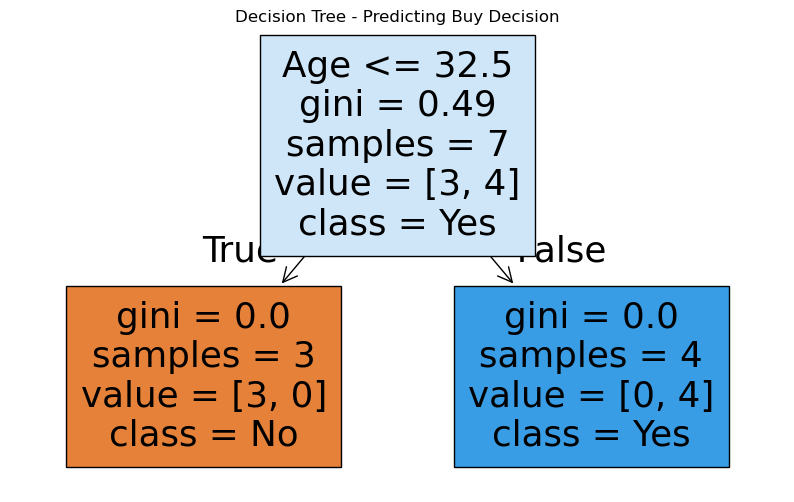

In [16]:
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.title('Decision Tree - Predicting Buy Decision')
plt.show()